![Built with AI](https://img.shields.io/badge/Built%20with-AI-blue.svg)

# Laboratorio — Almacenamiento en disco y desempeño de I/O

Este notebook es la parte práctica del laboratorio de acceso a disco. Permite medir y comparar:

- acceso secuencial vs acceso aleatorio
- distintos tamaños de bloque
- resultados empíricos vs estimaciones teóricas

---

## Cómo usar este notebook

En este laboratorio encontrará tres tipos de secciones:

- **Ejecute esta celda:** contiene código listo para usar.
- **Analice:** debe interpretar los resultados obtenidos.
- **Conclusión:** debe redactar una respuesta breve con sus hallazgos.

> **Recomendación:** antes de ejecutar todo, revise la sección de
> **configuración** para ajustar el tamaño del archivo y el número de
> lecturas aleatorias según la capacidad de su equipo.

> **Recursos de apoyo:** las figuras de referencia para este laboratorio
> se encuentran en el `README.md` de la guía:
> - **fig1** — Jerarquía de memoria y latencias de referencia
> - **fig2** — Modelo de costo I/O y sus componentes
> - **fig3** — Comparación visual: acceso secuencial vs aleatorio
>
> Se recomienda tenerlas a mano mientras ejecuta el notebook.

## 0. Verificación del entorno

Ejecute la siguiente celda antes de continuar. Confirmará que todas
las librerías necesarias están disponibles en su entorno.

Si alguna librería aparece marcada con ✗, instálela con:

```bash
pip install nombre_libreria
```

En Google Colab todas las librerías ya están disponibles.

In [1]:
import sys
import importlib

librerias_requeridas = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'matplotlib': 'matplotlib',
}

print(f'Python: {sys.version}')
print('-' * 40)

todo_ok = True
for nombre, modulo in librerias_requeridas.items():
    try:
        lib = importlib.import_module(modulo)
        version = getattr(lib, '__version__', 'versión no disponible')
        print(f'✓ {nombre} {version}')
    except ImportError:
        print(f'✗ {nombre} — NO encontrada. Instale con: pip install {nombre}')
        todo_ok = False

print('-' * 40)
if todo_ok:
    print('Entorno listo. Puede continuar con el laboratorio.')
else:
    print('Corrija las dependencias faltantes antes de continuar.')

Python: 3.12.5 (tags/v3.12.5:ff3bc82, Aug  6 2024, 20:45:27) [MSC v.1940 64 bit (AMD64)]
----------------------------------------
✓ numpy 2.1.1
✓ pandas 2.2.2
✓ matplotlib 3.9.2
----------------------------------------
Entorno listo. Puede continuar con el laboratorio.


## 1. Objetivos del notebook

Al finalizar esta práctica debería poder:

1. Entender cómo afecta el patrón de acceso al rendimiento.
2. Medir tiempos de lectura secuencial y aleatoria.
3. Calcular throughput empírico.
4. Comparar mediciones con un modelo teórico simple de I/O.
5. Visualizar los resultados con gráficas automáticas.

In [2]:
import os
import time
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print('Entorno listo.')

Entorno listo.


## 2. Recordatorio teórico

Antes de iniciar las mediciones, repase los conceptos clave que
usará a lo largo del experimento.

### Jerarquía de memoria y costo de acceso

Los dispositivos de almacenamiento tienen latencias muy distintas.
Un acceso a RAM toma nanosegundos; un acceso a disco puede tomar
milisegundos — una diferencia de hasta un millón de veces. Por eso
los sistemas están diseñados para minimizar los accesos a disco.

### Bloques de I/O

El disco no lee bytes individuales — lee **bloques completos**.
Incluso si un programa solicita 1 byte, el sistema transfiere todo
el bloque (típicamente 4 KB en sistemas operativos, 4–16 KB en
motores de bases de datos).

### Patrones de acceso

- **Secuencial:** los bloques se leen uno tras otro en posiciones
  contiguas. El número de accesos físicos al disco es mínimo (M ≈ 1).
- **Aleatorio:** cada bloque está en una posición distinta del disco.
  Cada acceso requiere posicionamiento independiente, por lo que M
  puede ser muy grande.

### Modelo de costo I/O

$$TotalTime = AccessLatency \times M + \frac{DataSize}{ScanThroughput}$$

- **AccessLatency:** tiempo para acceder al inicio de un bloque.
- **M:** número de accesos no contiguos al disco.
- **DataSize:** volumen total de datos a leer.
- **ScanThroughput:** velocidad de lectura sostenida del dispositivo.

> **Conexión con clase:** en las diapositivas se estudió el modelo
> detallado del HDD: $T_{access} = T_{seek} + T_{rotation} + T_{transfer}$.
> En este laboratorio, $AccessLatency$ agrupa $T_{seek}$ y $T_{rotation}$
> en un único valor promedio. Esta simplificación permite comparar
> tecnologías distintas (HDD, SSD, NVMe) con la misma fórmula.

## Punto de control 1 — Revisión conceptual

Antes de continuar, responda brevemente:

1. ¿Qué representa la latencia en este laboratorio?
2. ¿Qué representa el throughput?
3. ¿Por qué en acceso secuencial normalmente se asume que $M \approx 1$?
4. ¿Por qué en acceso aleatorio $M$ tiende a ser mayor?

> **Criterio mínimo:** cada respuesta debe tener al menos una oración
> propia. No copie definiciones — explíquelo con sus palabras.

### Respuestas

- Respuesta 1: Latencia representa el tiempo que va a tardar el sistema en empezar a acceder a los datos desde el disco una vez se haga una  solicitud; este tiempo es crítico ya que incluye el acceso al bloque de datos y suele ser uno de los factores que afecta el rendimiento en acceso al disco.
- Respuesta 2: El throughput representa la cantidad de datos que se pueden transferir por unidad de tiempo. En este laboratorio mide que tan rápido se pueden mover grandes volumenes de datos desde el disco hacia la memoria. Se diferencia de la latencia ya que aquí no importa el inicio de la operación, sino la velocidad durante la transferencia.
- Respuesta 3: En el acceso secuencial se asume como **M ≈ 1** ya que los datos se leen de manera contigua, lo que permite agrupar múltiples bloques en una sola operación. Esto reduce la cantidad de accesos al disco y hace que el costo de latencia se pague una sola vez.
- Respuesta 4: En el acceso aleatorio, **M** tiende a ser mayor ya que los datos se encuentran en diferentes posiciones del disco, esto obliga que el sistema realice múltiples accesos independientes.

## 3. Configuración del experimento

Puede ajustar estos parámetros según el tiempo disponible y la capacidad del entorno.

In [3]:
# ==============================
# CONFIGURACIÓN GENERAL
# ==============================

DATA_DIR = Path('io_lab_data')
DATA_DIR.mkdir(exist_ok=True)

FILE_PATH = DATA_DIR / 'dataset.bin'

# Tamaño del archivo a generar.
# En Colab se recomienda entre 128 y 512 MB.
FILE_SIZE_MB = 256

# Tamaños de bloque a comparar
BLOCK_SIZES = [4 * 1024, 16 * 1024, 64 * 1024, 256 * 1024]

# Número de lecturas aleatorias por tamaño de bloque
RANDOM_READS = 4000

# Semilla para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print('Archivo:', FILE_PATH)
print('Tamaño objetivo (MB):', FILE_SIZE_MB)
print('Bloques a probar (bytes):', BLOCK_SIZES)
print('Número de lecturas aleatorias:', RANDOM_READS)

Archivo: io_lab_data\dataset.bin
Tamaño objetivo (MB): 256
Bloques a probar (bytes): [4096, 16384, 65536, 262144]
Número de lecturas aleatorias: 4000


## Punto de control 2 — Reflexión sobre la configuración

Observe los parámetros impresos por la celda anterior y responda:

1. **Tamaño del archivo:** ¿Es suficiente para superar la caché RAM de
   su equipo? Compare con los valores de RAM registrados en la Etapa 1
   de la guía.

2. **Tamaño de bloque:** Los tamaños evaluados (4 KB, 16 KB, 64 KB,
   256 KB) corresponden a tamaños típicos de páginas en sistemas
   operativos y motores de bases de datos. ¿Cuál esperaría que tuviera
   mejor rendimiento en acceso aleatorio y por qué?

3. **Entorno de ejecución:** ¿Está ejecutando en local o en Google Colab?
   Recuerde que en Colab los tiempos medidos corresponden al hardware de
   Google, no al suyo.

### Respuestas

- Respuesta 1: El archivo tiene un tamaño de 256 MB, lo cual generalmente no es duficiente para superar la caché de la memoria RAM, lo que provoca que las lecturas de hagan desde la RAM en lugar del disco. Estó podría arrojar resultados más rápidos.
- Respuesta 2: Se espera que el tamaño de bloque 256 KB tenga un mejor rendimiento en acceso aleatorio. Esto se debe a que los bloques más grandes reducen la cantidad de accesos al disco, disminuyendo el impacto de la latencia.
- Respuesta 3: El experimento se está ejecutando en local, haciendo uso de el notebook desde VS code, esto significa que los resultados optenidos dependen directamete del equipo (CPU, RAN Disco).

### Reinicio del experimento

Si desea cambiar el tamaño del archivo de prueba y repetir el
experimento desde cero, ejecute la siguiente celda antes de continuar.
Esto eliminará el archivo generado anteriormente y forzará su
recreación con los nuevos parámetros.

> **Nota:** en condiciones normales no es necesario ejecutar esta
> celda. Omítala si es la primera vez que corre el notebook.

In [ ]:
# ==============================
# REINICIO DEL EXPERIMENTO
# (opcional — solo si cambió FILE_SIZE_MB)
# ==============================

import shutil

RESET = False  # Cambie a True para eliminar el archivo de prueba

if RESET:
    if DATA_DIR.exists():
        shutil.rmtree(DATA_DIR)
        DATA_DIR.mkdir(exist_ok=True)
        print(f'Carpeta {DATA_DIR} eliminada. El archivo se recreará en la siguiente sección.')
    else:
        print('No hay archivos previos que eliminar.')
else:
    print('RESET = False. No se eliminó ningún archivo.')
    print('Cambie RESET = True si desea repetir el experimento con nuevos parámetros.')

## 4. Crear el archivo de prueba

Este archivo simula datos almacenados en disco. Solo se crea si todavía
no existe o si su tamaño no coincide con la configuración actual.

In [4]:
def create_test_file(file_path: Path, size_mb: int, chunk_mb: int = 8) -> None:
    """Crea un archivo binario grande para pruebas de I/O.

    Parámetros:
        file_path: ruta del archivo a crear.
        size_mb: tamaño total del archivo en MB.
        chunk_mb: tamaño del bloque con el que se escribe el archivo.
    """
    target_size = size_mb * 1024 * 1024
    if file_path.exists() and file_path.stat().st_size == target_size:
        print('El archivo ya existe y tiene el tamaño esperado.')
        return

    print(f'Creando archivo de {size_mb} MB...')
    chunk_bytes = chunk_mb * 1024 * 1024
    remaining = target_size

    with open(file_path, 'wb') as f:
        while remaining > 0:
            current = min(chunk_bytes, remaining)
            f.write(os.urandom(current))
            remaining -= current

    print('Archivo creado correctamente.')


create_test_file(FILE_PATH, FILE_SIZE_MB)
print('Tamaño final del archivo (bytes):', FILE_PATH.stat().st_size)

Creando archivo de 256 MB...
Archivo creado correctamente.
Tamaño final del archivo (bytes): 268435456


## Analice

Después de crear el archivo, responda:

1. ¿Qué papel cumple este archivo dentro del experimento?
2. ¿Por qué es útil trabajar con un archivo relativamente grande?
3. ¿Qué cree que ocurriría si el archivo fuera demasiado pequeño?

> **Criterio mínimo:** la respuesta 3 debe mencionar explícitamente
> el concepto de caché del sistema operativo.

### Respuestas

- Respuesta 1: Dentro del experimento el archivo creado cumple el papel de ser el conjunto de datos sobre el cual se van a hacer las pruebas de lectura, es decir, actuará como la fuente de información desde donde el sistema medirá el rendimiento del disco, permitiendo evaluar tanto el acceso de secuencia como el acceso aleatorio. Sin la existencia de este archivo, no sería posible simular operaciones reales de I/O ni hacer el análisis del comportamiento del hardware.
- Respuesta 2: Trabajar con un archivo relativamente grande es muy útil ya que permite hacer una aproximación real al comportamiento del disco y asi evitar que las mediciones estén dominadas por la memoria RAM. Cuando se tiene un archivo lo suficientemente grande, el sistema no puede mantener todos los datos en memoria, por lo que se ve en la obligación de acceder al almacenamiento físico, haciendo que los resultados sean más representativos del rendimiento real del dispositivo.
- Respuesta 3: Si el archivo fuero demasiado pequeño, el sistema operativo podría almacenarlo completamente en la memoria RAM, esto hace que las lecturas se realicen desde la memoria en lugar del disco. Esto provoca tiempos de acceso más bajos y velocidades altas, distorsionando los resultados del experimento. En consecuencia no se estaría midiendo el rendimiento real del dispositivo, sino de la memoria, por lo que el análisis sería inválido.

## 5. Funciones auxiliares de medición

In [5]:
def format_bytes(num_bytes: int) -> str:
    """Convierte un tamaño en bytes a una representación legible."""
    units = ['B', 'KB', 'MB', 'GB', 'TB']
    value = float(num_bytes)
    for unit in units:
        if value < 1024 or unit == units[-1]:
            return f'{value:.2f} {unit}'
        value /= 1024


def throughput_mib_s(total_bytes: int, elapsed_seconds: float) -> float:
    """Calcula throughput en MiB/s."""
    if elapsed_seconds <= 0:
        return float('inf')
    return (total_bytes / (1024 * 1024)) / elapsed_seconds


def sequential_read_measure(file_path: Path, block_size: int) -> dict:
    """Mide lectura secuencial del archivo completo."""
    total_bytes = 0
    start = time.perf_counter()
    with open(file_path, 'rb', buffering=0) as f:
        while True:
            chunk = f.read(block_size)
            if not chunk:
                break
            total_bytes += len(chunk)
    elapsed = time.perf_counter() - start
    return {
        'pattern': 'Secuencial',
        'block_size_bytes': block_size,
        'total_bytes': total_bytes,
        'operations': math.ceil(total_bytes / block_size),
        'elapsed_s': elapsed,
        'throughput_mib_s': throughput_mib_s(total_bytes, elapsed),
    }


def random_read_measure(file_path: Path, block_size: int, reads: int) -> dict:
    """Mide lectura aleatoria de bloques en posiciones dispersas."""
    file_size = file_path.stat().st_size
    max_offset = file_size - block_size
    if max_offset <= 0:
        raise ValueError('El archivo es más pequeño que el tamaño de bloque.')

    offsets = np.random.randint(0, max_offset + 1, size=reads)
    total_bytes = 0

    start = time.perf_counter()
    with open(file_path, 'rb', buffering=0) as f:
        for offset in offsets:
            f.seek(int(offset))
            chunk = f.read(block_size)
            total_bytes += len(chunk)
    elapsed = time.perf_counter() - start
    return {
        'pattern': 'Aleatorio',
        'block_size_bytes': block_size,
        'total_bytes': total_bytes,
        'operations': reads,
        'elapsed_s': elapsed,
        'throughput_mib_s': throughput_mib_s(total_bytes, elapsed),
    }

## 6. Ejecutar experimentos empíricos

Se ejecutará la medición para cada tamaño de bloque, comparando acceso
secuencial y aleatorio.

In [6]:
results = []

for block_size in BLOCK_SIZES:
    print(f'\nProbando bloque = {format_bytes(block_size)}')

    seq_result = sequential_read_measure(FILE_PATH, block_size)
    rnd_result = random_read_measure(FILE_PATH, block_size, RANDOM_READS)

    results.append(seq_result)
    results.append(rnd_result)

    print(f"Secuencial -> tiempo: {seq_result['elapsed_s']:.4f} s, throughput: {seq_result['throughput_mib_s']:.2f} MiB/s")
    print(f"Aleatorio  -> tiempo: {rnd_result['elapsed_s']:.4f} s, throughput: {rnd_result['throughput_mib_s']:.2f} MiB/s")

df_empirical = pd.DataFrame(results)
df_empirical['block_size_kib'] = df_empirical['block_size_bytes'] / 1024
df_empirical


Probando bloque = 4.00 KB
Secuencial -> tiempo: 0.5690 s, throughput: 449.90 MiB/s
Aleatorio  -> tiempo: 0.1164 s, throughput: 134.22 MiB/s

Probando bloque = 16.00 KB
Secuencial -> tiempo: 0.4253 s, throughput: 601.99 MiB/s
Aleatorio  -> tiempo: 0.0747 s, throughput: 836.78 MiB/s

Probando bloque = 64.00 KB
Secuencial -> tiempo: 0.1920 s, throughput: 1333.67 MiB/s
Aleatorio  -> tiempo: 0.1516 s, throughput: 1649.12 MiB/s

Probando bloque = 256.00 KB
Secuencial -> tiempo: 0.1348 s, throughput: 1898.88 MiB/s
Aleatorio  -> tiempo: 0.5149 s, throughput: 1942.06 MiB/s


,pattern,block_size_bytes,total_bytes,operations,elapsed_s,throughput_mib_s,block_size_kib
0,Secuencial,4096,268435456,65536,0.569017,449.898369,4.0
1,Aleatorio,4096,16384000,4000,0.116410,134.223980,4.0
2,Secuencial,16384,268435456,16384,0.425258,601.987499,16.0
3,Aleatorio,16384,65536000,4000,0.074691,836.778633,16.0
4,Secuencial,65536,268435456,4096,0.191951,1333.670225,64.0
5,Aleatorio,65536,262144000,4000,0.151596,1649.124381,64.0
6,Secuencial,262144,268435456,1024,0.134816,1898.881588,256.0
7,Aleatorio,262144,1048576000,4000,0.514916,1942.063959,256.0


## Análisis de resultados empíricos

Observe la tabla generada y responda:

1. ¿Cuál patrón de acceso fue más rápido para cada tamaño de bloque?
2. ¿El throughput cambió al aumentar el tamaño de bloque?
3. ¿En qué caso observó la mayor diferencia entre secuencial y aleatorio?

> **Criterio mínimo:** la respuesta 3 debe incluir valores numéricos
> concretos obtenidos de la tabla (throughput en MiB/s o tiempo en s).

### Respuesta

- Pregunta 1: El patrón de acceso va variando de acuerdo al tamaño del bloque y la métrica analizada. Para el bloque de 4 KB, el acceso aleatorio presenta menor tiempo (0.1164 s frente a 0.5690 s), aunque su throughput es mucho menor (134.22 MiB/s frente a 449.90 MiB/s), esto indica menor eficiencia. En bloques de 16 KB y 64 KB, el acceso aleatorio es más rápido tanto en tiempo como en throughput (por ejemplo, en 64 KB alcanza 1649.12 MiB/s frente a 1333.67 MiB/s del secuencial). Sin embargo, en bloques de 256 KB el acceso secuencial resulta más rápido en tiempo (0.1348 s frente a 0.5149 s), aunque el throughput del aleatorio es ligeramente mayor (1942.06 MiB/s frente a 1898.88 MiB/s). En conclusión, podemos observar que el patrón más rápido depende de cómo se mida (tiempo o throughput) y del tamaño de bloque.
- Pregunta 2: El throughput sí cambia al aumentar el tamaño de bloque, mostrando un incremento significativo en ambos patrones de acceso. Por ejemplo, en el acceso secuencial con bloques de 4 KB pasa de 449.90 MiB/s a 1898.88 MiB/s con bloques de 256 KB, mientras que en el acceso aleatorio pasa de 134.22 MiB/s a 1942.06 MiB/s. Esto se debe a que bloques más grandes reducen la cantidad de accesos al disco, disminuyendo el impacto de la latencia y mejorando la eficiencia de transferencia.
- Pregunta 3: La mayor diferencia entre acceso secuencial y aleatorio se puede observar en el tamaño de bloque de 4 KB. En este caso, el acceso secuencial alcanza un throughput de 449.90 MiB/s, mientras que el acceso aleatorio solo llega a 134.22 MiB/s, lo que representa una diferencia aproximada de 315.68 MiB/s. Esta gran diferencia evidencia que el acceso aleatorio es mucho menos eficiente en bloques pequeños debido a su alto costo de la latencia, mientras que a medida que el tamaño de bloque aumenta, esta diferencia se reduce.


## 7. Modelo teórico de costo I/O

En esta sección se calculan los tiempos esperados según el modelo
simplificado visto en clase. Estos valores servirán como referencia
para comparar con sus mediciones empíricas.

### Parámetros del dispositivo teórico

Los parámetros a continuación representan un dispositivo de referencia.
Puede ajustarlos para modelar el comportamiento esperado de su equipo:

| Dispositivo | AccessLatency | ScanThroughput |
|---|---|---|
| SSD NVMe (defecto) | 10 µs | 5 GB/s |
| SSD SATA | 100 µs | 500 MB/s |
| HDD | 10 ms | 100 MB/s |

> **Nota:** el parámetro `AccessLatency` de este modelo corresponde
> a la suma de $T_{seek} + T_{rotation}$ del modelo de HDD visto en
> clase. Para un SSD no existe seek ni rotación, pero sí existe una
> latencia del controlador que cumple el mismo rol en la fórmula.
> Ajuste el dispositivo modelado según la tecnología registrada en
> su tabla de caracterización de la Etapa 1.

In [16]:
# ==============================
# PARÁMETROS TEÓRICOS
# ==============================

THEORY_DEVICE = {
    'name': 'SSD aproximado',
    'access_latency_s': 10e-6,
    'scan_throughput_bytes_s': 5 * (1024**3),
}

# Si quiere modelar un HDD, puede descomentar esto:
# THEORY_DEVICE = {
#     'name': 'HDD aproximado',
#     'access_latency_s': 10e-3,
#     'scan_throughput_bytes_s': 100 * (1024**2),
# }

print(THEORY_DEVICE)

{'name': 'SSD aproximado', 'access_latency_s': 1e-05, 'scan_throughput_bytes_s': 5368709120}


## Punto de control 3 — Modelo teórico elegido

Indique cuál dispositivo teórico usó para comparar sus resultados:

- Dispositivo modelado: SSD NVMe
- Latencia asumida: 10 µs
- Throughput asumido: 5 GB/s

Luego explique por qué ese modelo podría parecerse o no a su entorno real.

- Este modelo puede parecerse parcialmente al entorno real ya que mi equipo cuenta con un SDD moderno. Sin embargo es importante tener en cuenta que en la práctica existen diferencias importantes debido a factores como la sobrecarga del sistema operativo, el uso de caché, la fragmentación de datos y la carga del sistema, los cuales no son considerados en el modelo teórico. Además, el modelo asume condiciones ideales donde el dispositivo opera a máxima capacidad de forma constante, lo cual rara vez ocurre en un entorno real.

In [8]:
def theoretical_io_time(
    data_size_bytes: int,
    m_accesses: int,
    access_latency_s: float,
    scan_throughput_bytes_s: float
) -> float:
    """Aplica el modelo simplificado de costo I/O."""
    return access_latency_s * m_accesses + (data_size_bytes / scan_throughput_bytes_s)


theory_rows = []
file_size = FILE_PATH.stat().st_size

for block_size in BLOCK_SIZES:
    seq_data_size = file_size
    seq_m = 1
    seq_time = theoretical_io_time(
        data_size_bytes=seq_data_size,
        m_accesses=seq_m,
        access_latency_s=THEORY_DEVICE['access_latency_s'],
        scan_throughput_bytes_s=THEORY_DEVICE['scan_throughput_bytes_s'],
    )

    theory_rows.append({
        'pattern': 'Secuencial',
        'block_size_bytes': block_size,
        'block_size_kib': block_size / 1024,
        'theoretical_elapsed_s': seq_time,
        'theoretical_throughput_mib_s': throughput_mib_s(seq_data_size, seq_time),
    })

    rnd_data_size = block_size * RANDOM_READS
    rnd_m = RANDOM_READS
    rnd_time = theoretical_io_time(
        data_size_bytes=rnd_data_size,
        m_accesses=rnd_m,
        access_latency_s=THEORY_DEVICE['access_latency_s'],
        scan_throughput_bytes_s=THEORY_DEVICE['scan_throughput_bytes_s'],
    )

    theory_rows.append({
        'pattern': 'Aleatorio',
        'block_size_bytes': block_size,
        'block_size_kib': block_size / 1024,
        'theoretical_elapsed_s': rnd_time,
        'theoretical_throughput_mib_s': throughput_mib_s(rnd_data_size, rnd_time),
    })

df_theory = pd.DataFrame(theory_rows)
df_theory

,pattern,block_size_bytes,block_size_kib,theoretical_elapsed_s,theoretical_throughput_mib_s
0,Secuencial,4096,4.0,0.050010,5118.976205
1,Aleatorio,4096,4.0,0.043052,362.935239
2,Secuencial,16384,16.0,0.050010,5118.976205
3,Aleatorio,16384,16.0,0.052207,1197.156753
4,Secuencial,65536,64.0,0.050010,5118.976205
5,Aleatorio,65536,64.0,0.088828,2814.423923
6,Secuencial,262144,256.0,0.050010,5118.976205
7,Aleatorio,262144,256.0,0.235313,4249.667995


## 8. Comparación entre resultados empíricos y teóricos

In [9]:
df_compare = df_empirical.merge(
    df_theory,
    on=['pattern', 'block_size_bytes', 'block_size_kib'],
    how='left'
)

df_compare['elapsed_ratio_empirical_vs_theoretical'] = (
    df_compare['elapsed_s'] / df_compare['theoretical_elapsed_s']
)

df_compare['throughput_ratio_empirical_vs_theoretical'] = (
    df_compare['throughput_mib_s'] / df_compare['theoretical_throughput_mib_s']
)

df_compare

,pattern,block_size_bytes,total_bytes,operations,elapsed_s,throughput_mib_s,block_size_kib,theoretical_elapsed_s,theoretical_throughput_mib_s,elapsed_ratio_empirical_vs_theoretical,throughput_ratio_empirical_vs_theoretical
0,Secuencial,4096,268435456,65536,0.569017,449.898369,4.0,0.050010,5118.976205,11.378072,0.087888
1,Aleatorio,4096,16384000,4000,0.116410,134.223980,4.0,0.043052,362.935239,2.703952,0.369829
2,Secuencial,16384,268435456,16384,0.425258,601.987499,16.0,0.050010,5118.976205,8.503459,0.117599
3,Aleatorio,16384,65536000,4000,0.074691,836.778633,16.0,0.052207,1197.156753,1.430673,0.698972
4,Secuencial,65536,268435456,4096,0.191951,1333.670225,64.0,0.050010,5118.976205,3.838262,0.260535
5,Aleatorio,65536,262144000,4000,0.151596,1649.124381,64.0,0.088828,2814.423923,1.706617,0.585955
6,Secuencial,262144,268435456,1024,0.134816,1898.881588,256.0,0.050010,5118.976205,2.695785,0.370949
7,Aleatorio,262144,1048576000,4000,0.514916,1942.063959,256.0,0.235313,4249.667995,2.188222,0.456992


## Análisis comparativo: teoría vs práctica

Interprete la tabla comparativa:

1. ¿Los tiempos empíricos son mayores o menores que los teóricos?
2. ¿En cuál patrón de acceso la teoría se aproxima mejor?
3. ¿Qué factores reales podrían explicar las diferencias?

> **Criterio mínimo:** la respuesta 3 debe mencionar al menos dos
> factores concretos (por ejemplo: caché del SO, temperatura,
> carga del sistema, tipo de disco).

### Respuesta

- Pregunta 1: Los tiempos empíricos son mayores que los teóricos en todos los casos. Esto nos indica que en la práctica el sistema tarda más tiempo en realizar las operaciones que lo que se predice en el modelo teórico, el cual asume condiciones ideales.
- Pregunta 2: La teoría se aproxima mejor al acceso aleatorio, ya que los valores del ratio son más cercanos a 1 en comparación con el acceso secuencial. Por ejemplo, se obseva en los accesos aleatorios valores como **1.43** y **1.70**, mientras que en el acceso secuencial los valores son mayores **11.37** y **8.50**, esto indica una mayor desviación respecto al modelo teórico.
Esto indica que el modelo teórico representa mejor el comportamiento del acceso aleatorio que el secuencial en este experimento.
- Pregunta 3: Las diferencias entre los resultados empíricos y teóricos pueden explicarse por varios factores que no están contemplados en el modelo ideal. Entre ellos se encuentran:
    - Caché del sistema operativo, que puede acelerar o alterar las lecturas dependiendo de si los datos ya están en memoria.
    - Carga del sistema, ya que otros procesos pueden consumir CPU o disco y afectar los tiempos de respuesta.
    - Tipo de disco y su estado, incluyendo limitaciones del hardware, controladores o fragmentación.
    -Temperatura del dispositivo, que puede provocar reducción de rendimiento (thermal throttling) en discos SSD.
    
Estos factores hacen que el comportamiento real del sistema sea más variable y generalmente más lento que el modelo teórico.

## 9. Gráficas automáticas

Las siguientes gráficas se generan a partir de los resultados del
experimento y se guardan automáticamente en la carpeta `images/`
para que pueda incluirlas en su informe.

In [10]:
# ==============================
# CONFIGURACIÓN DE EXPORTACIÓN
# ==============================

IMAGES_DIR = Path('images')
IMAGES_DIR.mkdir(exist_ok=True)

print(f'Las gráficas se guardarán en: {IMAGES_DIR.resolve()}')

Las gráficas se guardarán en: C:\Users\user\AppData\Local\Temp\LABS_Estructura_de_Datos\lab3-IO_performance-ValentinaGarro\images


Guardada: fig_throughput.png


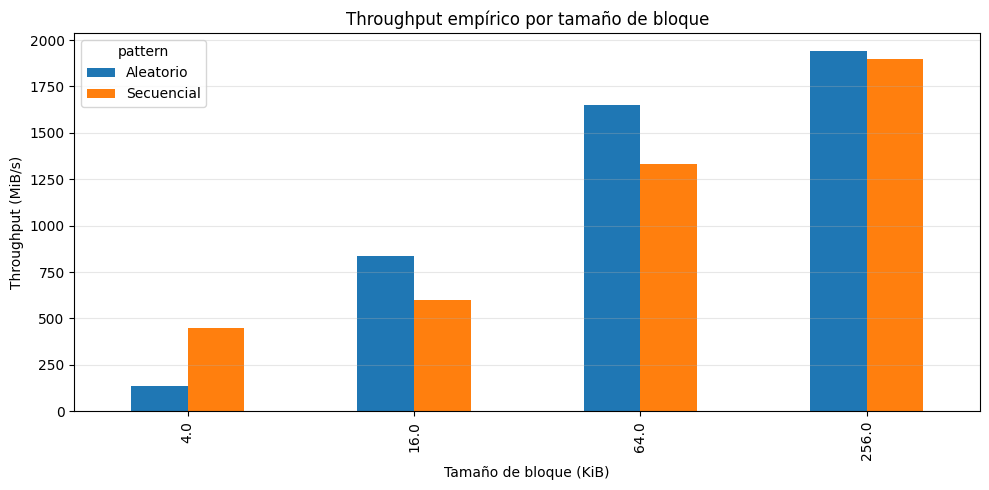

In [11]:
def plot_empirical_throughput(df: pd.DataFrame) -> None:
    """Grafica throughput empírico para secuencial y aleatorio."""
    pivot = df.pivot(
        index='block_size_kib',
        columns='pattern',
        values='throughput_mib_s'
    ).sort_index()
    ax = pivot.plot(kind='bar', figsize=(10, 5))
    ax.set_title('Throughput empírico por tamaño de bloque')
    ax.set_xlabel('Tamaño de bloque (KiB)')
    ax.set_ylabel('Throughput (MiB/s)')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / 'fig_throughput.png', dpi=150, bbox_inches='tight')
    print('Guardada: fig_throughput.png')
    plt.show()


plot_empirical_throughput(df_empirical)

## Interprete la gráfica de throughput

Describa con sus palabras qué muestra esta gráfica:
 
- ¿Qué barras son más altas?
- ¿Qué significa eso en términos de rendimiento?
- ¿Cuál patrón aprovecha mejor la lectura en bloques?

> **Criterio mínimo:** mencione al menos un tamaño de bloque específico
> y su valor de throughput observado.

### Respuesta

    - En la gráfica podemos observar que para 16, 64 y 256 KiB las barras más altas son las del acceso aleatorio, mientras que  en 4 KiB la barra más alta es la de acceso secuencial.
    - Esto significa en términos de rendimiento que a mayor altura = mayor throughput, es decir, un mejor rendimiento en la lectura de datos. Por ejemplo para 256 KiB el aleatorio alcanza ≈ 1942 MiB/s.
    - En general, el patrón aleatorio aprovecha mejor la lectura en bloques grandes, superando al secuencial en casi todos los tamaños excepto en el más pequeño.

Guardada: fig_tiempo_empirico.png


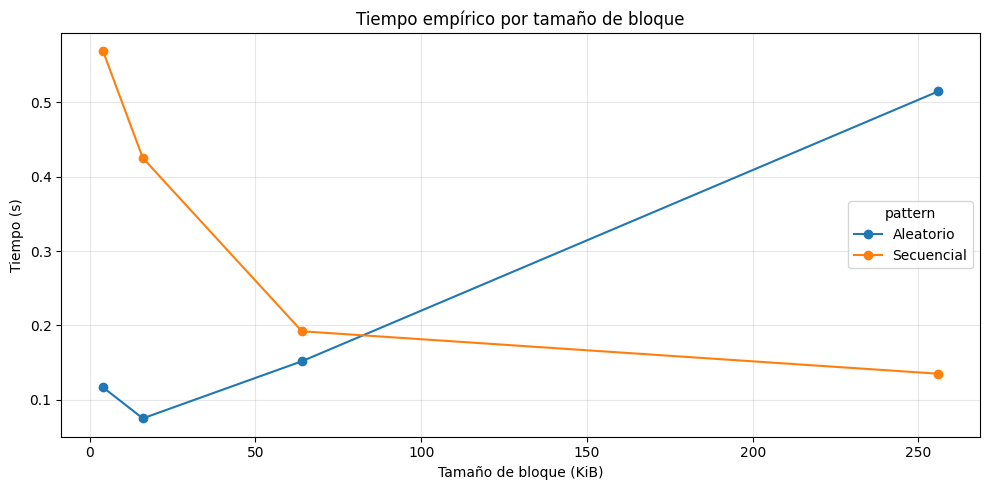

In [12]:
def plot_empirical_time(df: pd.DataFrame) -> None:
    """Grafica tiempo empírico por patrón de acceso."""
    pivot = df.pivot(
        index='block_size_kib',
        columns='pattern',
        values='elapsed_s'
    ).sort_index()
    ax = pivot.plot(marker='o', figsize=(10, 5))
    ax.set_title('Tiempo empírico por tamaño de bloque')
    ax.set_xlabel('Tamaño de bloque (KiB)')
    ax.set_ylabel('Tiempo (s)')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / 'fig_tiempo_empirico.png', dpi=150, bbox_inches='tight')
    print('Guardada: fig_tiempo_empirico.png')
    plt.show()


plot_empirical_time(df_empirical)

## Interprete la gráfica de tiempo

Explique cómo cambia el tiempo total cuando cambia el tamaño de bloque.

> **Criterio mínimo:** compare el comportamiento de la curva secuencial
> con la aleatorio e indique en qué punto divergen más.

### Respuesta

    - Podemos observar que el tiempo secuencial disminuye al aumentar el tamaño de bloque (de ≈ 0.57 s en 4 KiB a ≈ 0.13 s en 256 KiB), mientras que en el aleatorio tiende a aumentar (de ≈ 0.07–0.11 s hasta ≈ 0.51 s).
    La mayor diferencia se evidencia en 256 KiB, donde el aleatorio ≈ 0.51 s es mayor que el secuencial ≈ 0.13 s, mostrando un comportamiento opuesto.

Guardada: fig_tiempo_teoria_vs_practica_secuencial.png


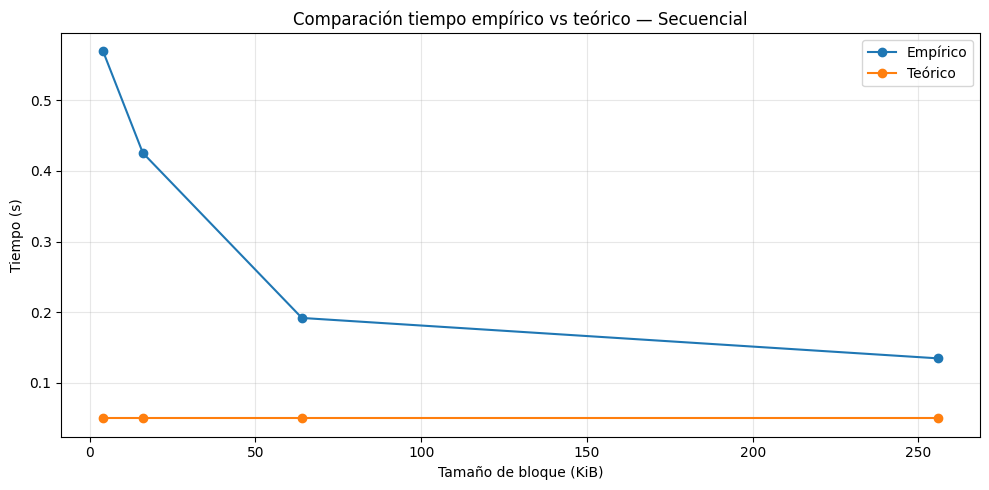

Guardada: fig_tiempo_teoria_vs_practica_aleatorio.png


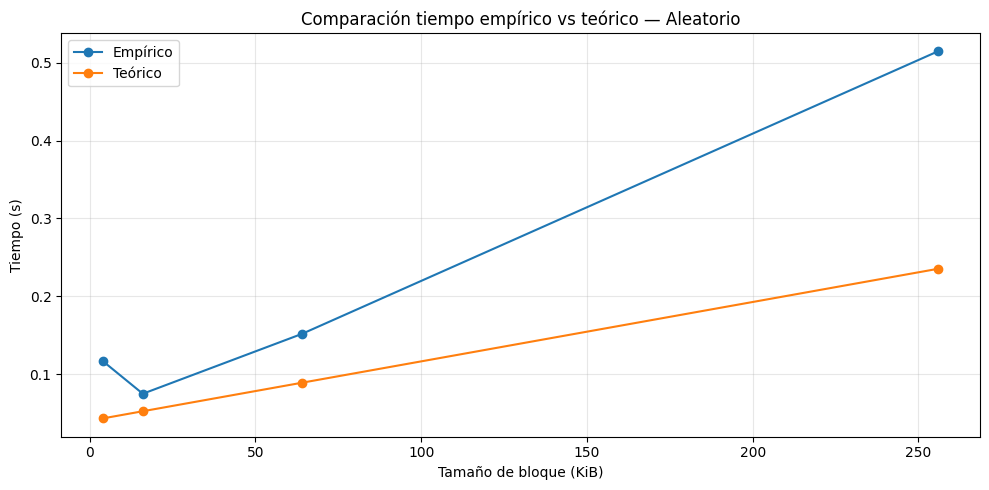

In [13]:
def plot_theory_vs_empirical(df: pd.DataFrame, pattern: str) -> None:
    """Compara tiempo empírico y teórico para un patrón dado."""
    subset = df[df['pattern'] == pattern].sort_values('block_size_kib')
    plt.figure(figsize=(10, 5))
    plt.plot(subset['block_size_kib'], subset['elapsed_s'],
             marker='o', label='Empírico')
    plt.plot(subset['block_size_kib'], subset['theoretical_elapsed_s'],
             marker='o', label='Teórico')
    plt.title(f'Comparación tiempo empírico vs teórico — {pattern}')
    plt.xlabel('Tamaño de bloque (KiB)')
    plt.ylabel('Tiempo (s)')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    nombre = f'fig_tiempo_teoria_vs_practica_{pattern.lower()}.png'
    plt.savefig(IMAGES_DIR / nombre, dpi=150, bbox_inches='tight')
    print(f'Guardada: {nombre}')
    plt.show()


plot_theory_vs_empirical(df_compare, 'Secuencial')
plot_theory_vs_empirical(df_compare, 'Aleatorio')

## Interprete la comparación empírico vs teórico

Observe las curvas y responda:

1. ¿Las curvas tienen una tendencia similar?
2. ¿Dónde se separan más?
3. ¿Qué le sugiere eso sobre el modelo usado?

> **Criterio mínimo:** la respuesta 3 debe indicar si el modelo
> sobreestima o subestima el tiempo real, y proponer una razón.

### Respuesta

    - En el tiempo secuencial las curvas no tienen una tendencia similar, lo podemos observar en la curva empírica decrece de ~0.57s a ~0.13s, mientras que la teórica permanece casi constante cerca de ~ 0.05s. Podemos decir que las tendencias son opuestas o independientes.
    En el tiempo aleatorio se observa que las curvas van creciendo con el tamaño de los bloques, compartiendo la misma tendencia general ascendentes, aunque con magnitudes distintas.
    - Para el tiempo secuencial se puede notar que la mayor separación ocurre en los bloques pequeños ≈ 2–4 KiB. A medida que el bloque crece, la brecha de separación se reduce pero no desaparece.
    Para el tiempo aleatorio para al contrario la separación es evidente con el tamaño de bloque y es máxima en el bloque ≈ 256 KiB donde el empírico marca ~0.51s y el teórico ~0.23s.
    - En ambos casos es evidente que el modelo subestima el tiempo real y lo notamos ya que la curva teórica está siempre por debajo de la empírica.
    Razones probables:
        - Secuencial: El modelo ignora el overhead de syscalls y latencia de inicio de I/O. Con bloques pequeños realiza muchas llamadas al sistema, donde el costo fijo domina. El modelo solo cuenta bytes transferidos, no el número de operaciones.
        - Aleatorio: El modelo subestima los fallos de caché de página. Donde con los bloques grandes, cada acceso aleatorio implica leer y descartar más datos irrelevantes, y el modelo no captura ese desperdicio de I/O.

Guardada: fig_speedup.png


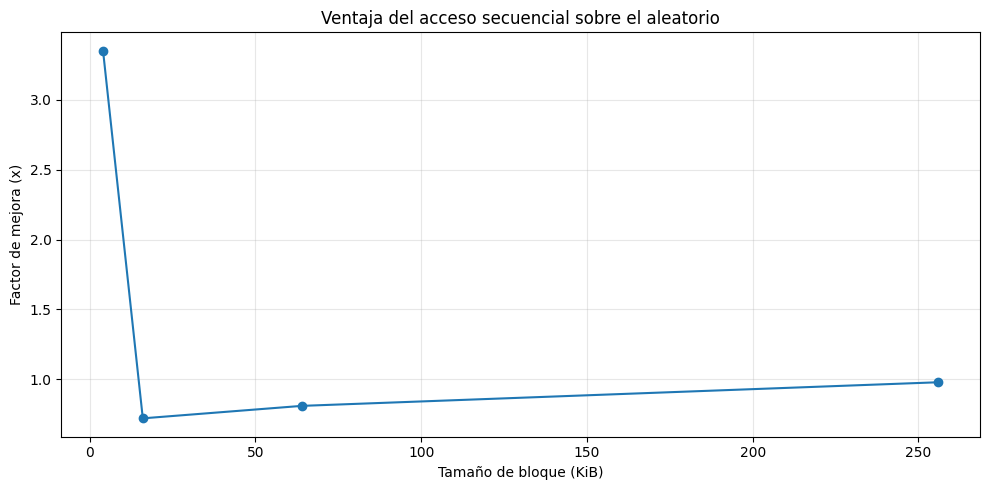

In [14]:
def plot_sequential_speedup(df: pd.DataFrame) -> None:
    """Grafica cuántas veces el acceso secuencial supera al aleatorio."""
    pivot = df.pivot(
        index='block_size_kib',
        columns='pattern',
        values='throughput_mib_s'
    ).sort_index()
    speedup = pivot['Secuencial'] / pivot['Aleatorio']
    ax = speedup.plot(marker='o', figsize=(10, 5))
    ax.set_title('Ventaja del acceso secuencial sobre el aleatorio')
    ax.set_xlabel('Tamaño de bloque (KiB)')
    ax.set_ylabel('Factor de mejora (x)')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / 'fig_speedup.png', dpi=150, bbox_inches='tight')
    print('Guardada: fig_speedup.png')
    plt.show()


plot_sequential_speedup(df_empirical)

## Interprete la ventaja del acceso secuencial

La gráfica muestra cuántas veces el acceso secuencial supera al aleatorio.

- ¿Cuál fue el mayor factor de mejora observado?
- ¿Cómo cambia esa ventaja con el tamaño de bloque?
- ¿Qué implicación tiene esto para el diseño de software?

> **Criterio mínimo:** incluya el valor numérico del mayor speedup
> observado y el tamaño de bloque en que ocurrió.

### Respuesta

- El mayor factor de mejora se obseerva en el pico que se observa en el bloque más pequeño 4 KiB, con un factor de mejora de ~3.3, es decir, el acceso secuencial fue ~3.3 veces más rápido que el aleatorio.
- La curva tiene 3 fases distinguibles:
    - Bloque que va desde 2 - 16 KiB caída drástica de ~3.3 a ~0.75
    - Bloque que va desde 16 - 64 KiB ligera recuperación aproximada ~0.83
    - Bloque que va desde 64 - 256 KiB presentando una convergencia lenta hacia 1.0
Alrededor del bloque 16 KiB se puede notar un punto notable donde el factor cae por debajo de 1.0, esto significa que en este rango el acceso aleatorio es por un momento más rápido que el secuencial.
Esto podría reflejar que con los bloques pequeños el seuencial aún carga overhead innecesario, mientras el aleatorio ya está "calentado" en caché.
- Algunas implicaciones para el diseño de software:
    - Optimizar para acceso secuencial tiene mayor retorno con datos pequeños y frecuentes.
    - Para bloques más grandes, el patrón de acceso es importante.
Se puede concluir que si el código maneja muchos accesos a fragmentos pequeños lo ideal sería agruparlos y acceder a ellos secuencialmente, mientras que si se manejan fragmentos más grandes ese esfuerzo raramente justifica la ganancia.

## 10. Resumen automático de resultados

In [15]:
summary_rows = []
for block_size in sorted(df_empirical['block_size_bytes'].unique()):
    seq = df_empirical[
        (df_empirical['block_size_bytes'] == block_size) &
        (df_empirical['pattern'] == 'Secuencial')
    ].iloc[0]
    rnd = df_empirical[
        (df_empirical['block_size_bytes'] == block_size) &
        (df_empirical['pattern'] == 'Aleatorio')
    ].iloc[0]
    summary_rows.append({
        'block_size_kib': block_size / 1024,
        'seq_time_s': seq['elapsed_s'],
        'rnd_time_s': rnd['elapsed_s'],
        'seq_throughput_mib_s': seq['throughput_mib_s'],
        'rnd_throughput_mib_s': rnd['throughput_mib_s'],
        'seq_vs_rnd_speedup': (
            seq['throughput_mib_s'] / rnd['throughput_mib_s']
            if rnd['throughput_mib_s'] > 0 else np.nan
        ),
    })

df_summary = pd.DataFrame(summary_rows)
df_summary

,block_size_kib,seq_time_s,rnd_time_s,seq_throughput_mib_s,rnd_throughput_mib_s,seq_vs_rnd_speedup
0,4.0,0.569017,0.116410,449.898369,134.223980,3.351848
1,16.0,0.425258,0.074691,601.987499,836.778633,0.719411
2,64.0,0.191951,0.151596,1333.670225,1649.124381,0.808714
3,256.0,0.134816,0.514916,1898.881588,1942.063959,0.977765


## Conclusión final

Redacte una conclusión de entre 8 y 12 líneas que integre los
siguientes elementos. Recuerde que esta conclusión también formará
parte de su informe en el `README.md` de entrega.

Su conclusión debe responder, en prosa continua y con sus propias
palabras, las siguientes preguntas:

- ¿Cómo se almacena la información en disco y por qué eso importa?
- ¿Por qué el acceso secuencial y el aleatorio tienen desempeños
  tan distintos, incluso en un SSD?
- ¿Qué tan bien predijo el modelo teórico el comportamiento real
  de su equipo?
- ¿Qué decisión de diseño tomaría en un sistema real con base en
  lo que midió?

> **Criterio mínimo:** la conclusión debe incluir al menos un valor
> numérico concreto de sus resultados (por ejemplo, el factor de
> speedup o el throughput secuencial medido) y conectarlo con uno
> de los conceptos teóricos del curso.

### Conclusión

- Podemos concluir que la información en el disco se almacena en bloques de tamaño fijo, los cuales contituyen la unidad mínima que el sistema operativo tiene la capacidad de leer o escribir en cada operación entrada - salida. Esta característica es clave, ya que define cuantas llamadas al sistema se necesitan para transferir cierta cantidad de datos y como consecuencia el nivel de sobrecarga asosiados a cada patrón de acceso. Aunque el SSDD se encarga de eliminar la latencia mecánica de los discos tradicionales, no suprime en su totalidad los costos derivados de las llamadas al sistema, ni la gestión de solicitudes. Por ello, el acceso aleatorio continua siendo más costoso que el secuencial. Esto se puede observar, en los bloques de 4 KiB, donde el acceso secuencial se tarda 0.57s frente a 0.12s del aleatorio, generando asi un speedup de 3.3x.
El modelo teórico, se basa en el ancho de la banda, subestimando asi los tiempos reales en ambos casos, prediciendo valores casi constantes para el acceso secuenial y un crecimiento moderado en el aleatorio, sin tener en cuenta la sobrecarga por operación ni la ineficiencia de leer bloques grandes dispersos. Estas diferencias dejan en eviencia que el modelo funciona como referencia, pero no como una representación real del comportamiento del hardware.
A partir de los resultados obtenidos anteriormente, se podría recomendar un entorno práctico para agrupar lecturas pequeñas en bloque de al menos 64 KiB, donde el rendimiento secuencial supera los 1300 MiB/s, con el fin de aprovechar mejor la caché del sistema operativo y reducir la cantidad de operaciones. El acceso aleatorio debería de reservarse para situaciones donde sea estrictamente necesario.

## 11. Preguntas de cierre

Responda en el `README.md` de su repositorio de entrega, apoyándose
en los resultados del experimento.

1. **Comparación de patrones:** Con base en sus mediciones, ¿cuántas
   veces más rápido fue el acceso secuencial respecto al aleatorio en
   su equipo? ¿Ese resultado era el esperado según la teoría?

2. **Efecto del tamaño de bloque:** ¿Qué ocurrió con el throughput del
   acceso aleatorio a medida que aumentó el tamaño de bloque?
   ¿Por qué cree que sucede eso?

3. **Teoría vs práctica:** Identifique un caso en sus resultados donde
   la medición empírica se alejó del modelo teórico. ¿A qué factor
   atribuye esa diferencia?

4. **Tipo de disco:** Compare sus resultados con los valores de referencia
   de la tabla de la guía. ¿Su equipo se comportó como un HDD, un SSD
   SATA o un SSD NVMe?

5. **Aplicación práctica:** Imagine que debe almacenar una tabla de
   estudiantes con 1 millón de registros. Con base en lo que midió,
   ¿preferiría leerla toda de forma secuencial o acceder a registros
   individuales de forma aleatoria? ¿Por qué?

## 12. Extensiones sugeridas

Si desea profundizar, puede ampliar el experimento de las siguientes formas:

- Repetir el experimento varias veces y promediar los resultados.
- Comparar lectura y escritura.
- Medir sobre SSD local vs disco de red.
- Cambiar el tamaño del archivo y observar el efecto en la caché.
- Comparar caché caliente vs caché fría ejecutando el benchmark dos veces seguidas.